SIGNATE「長期定着人材の予測」からの改善を整理するもの。  
「持っているデータの渡し方を変える」方向の改善を何点か実施している。  

1. 月次データの集約を拡張(傾き・前半vs後半の差・欠損率など角度を追加)
2. 自己学習（詳細）を分解して使う(テーマ名のテキスト+学習の幅・継続性)
3. テキストの扱いを TF-IDF+SVD から CatBoost の text_features に変更
4. 入社時メモの定型部分を正規表現でパースしてフラグ化(転居許容・在宅希望など)
5. 補助の目的変数として「在籍月数」の回帰モデルを作り、分類器に少しだけブレンド
6. シード平均(5シード)と、仕上げのPlatt較正

データはGoogleドライブに配置していることを前提とする。

＜注意＞　実行時間は1時間ほどかかります。急ぎの場合はシードを１つに減らすと10分程度で動作検証できます。

In [ ]:
# CatBoostと、日本語の特徴量名をグラフに出すためのライブラリに形態素解析(janome)を追加
!pip install catboost japanize-matplotlib janome -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 42.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 87.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# GoogleDriveのディレクトリを設定
データ置き場 = "/content/drive/MyDrive/Jaggle/syain"


Mounted at /content/drive


In [ ]:
# インポートを追加
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from janome.tokenizer import Tokenizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.model_selection import KFold, StratifiedKFold

# データ読み込み(shape=行数×列数。行数=人数の確認)
入社時データ_学習 = pd.read_csv(f"{データ置き場}/employee_persona_train.csv")
入社時データ_予測 = pd.read_csv(f"{データ置き場}/employee_persona_test.csv")
月次データ_学習 = pd.read_csv(f"{データ置き場}/employee_monthly_train.csv")
月次データ_予測 = pd.read_csv(f"{データ置き場}/employee_monthly_test.csv")
# 全期間版(〜120か月)を追加。用途は後述(特徴量ではなく目的変数側)
月次データ_学習_全期間 = pd.read_csv(f"{データ置き場}/employee_monthly_train_full.csv")

print("入社時データ_学習:", 入社時データ_学習.shape)
print("入社時データ_予測:", 入社時データ_予測.shape)
print("月次データ_学習 :", 月次データ_学習.shape)
print("月次データ_予測 :", 月次データ_予測.shape)
print("月次データ_学習_全期間:", 月次データ_学習_全期間.shape)

入社時データ_学習: (2761, 20)
入社時データ_予測: (2502, 19)
月次データ_学習 : (65754, 29)
月次データ_予測 : (60048, 29)
月次データ_学習_全期間: (257509, 29)


最初にデータを俯瞰する。確認の観点は前回版と同じ。全期間版のデータを増やしたので確認する。

- どんなパラメータを保有しているか
- trainとtestで何が違うか　とりあえず行頭・行末を５行ずつ
・・・全体感は対象ファイルをテキストで開いて確認

In [ ]:
データ一覧 = {
    "入社時データ_学習": 入社時データ_学習,
    "入社時データ_予測": 入社時データ_予測,
    "月次データ_学習": 月次データ_学習,
    "月次データ_予測": 月次データ_予測,
    "月次データ_学習_全期間": 月次データ_学習_全期間,
}
for データ名, データ in データ一覧.items():
    print(f"{データ名} 行頭")
    display(データ.head(5))
    print(f"{データ名} 行末")
    display(データ.tail(5))

入社時データ_学習 行頭


,社員ID,入社日,入社区分,入社時年齢,最終学歴,専攻分野,前職経験月数,前職職種,採用経路,性別,初期職種,初期部署ID,初期勤務地,初期等級,初期役割,初任給_円,入社時メモ,上司からのフィードバック,同僚からのフィードバック,10年定着ラベル
0,E000001,2012-03-01,中途,30,大学卒,人文・教養,84,コーポレート,人材紹介,男性,コーポレート,DEP_corporate_HOKKAIDO_00,北海道,G3,シニア,312000,・経歴：大学卒（人文・教養）。中途入社で、前職・初期職種はいずれもコーポレート。\n・人物所...,担当業務に慣れた時期には、うまくいかなかった進め方を振り返る際、助言や論点の整理があると次の...,日常の共同作業では、突発対応と定例業務が重なっても優先順位と完了条件を整理し、周囲が次に動き...,1
1,E000005,2013-04-01,中途,32,大学卒,人文・教養,120,リスク・金融・コンプライアンス,直接応募,女性,リスク・金融・コンプライアンス,DEP_risk_finance_compliance_TOKYO_29,東京,G3,シニア,350000,・経歴：大学卒。人文・教養系を専攻し、中途でリスク・金融・コンプライアンス領域に入社。前職も...,入社初期から、長期的に身につけたい経験や専門領域を具体的に捉え、役割が変わった後も一つの環境...,初めて担当する業務の引継ぎでは、優先順位や完了条件を自分で整理して進めるより、周囲から手順を...,1
2,E000007,2013-01-01,中途,29,大学卒,経済・経営,84,リスク・金融・コンプライアンス,社員紹介,男性,リスク・金融・コンプライアンス,DEP_risk_finance_compliance_OSAKA_08,大阪,G2,メンバー,307000,・経歴：大学卒。経済・経営系を専攻し、中途入社。前職・初期職種ともにリスク・金融・コンプライ...,入社初期、判断に迷う案件では抱え込まず、論点を整理して上司にレビューを依頼し、確認後は関係者...,途中から引き継いだ案件では、未整理だった情報を確認して優先順位と完了条件を整理し、次に必要な...,1
3,E000008,2013-04-01,新卒,25,大学院卒,理工学,0,NaN,直接応募,男性,データ・商品企画・コンサルティング,DEP_data_product_consulting_TOKYO_04,東京,G1,メンバー,280000,・経歴：大学院（理工学）卒。新卒でデータ・商品企画・コンサルティング領域に入社。\n・人物所...,直近では、役割変更後も従来と異なる手順の意図を確認し、自ら進め方を切り替えて周囲が次の作業に...,引継ぎでは、関係者ごとに異なっていた期待を確認し、優先順位と完了条件を整理して着地点を決めた...,1
4,E000010,2011-04-01,新卒,22,大学卒,その他,0,NaN,インターン,女性,コーポレート,DEP_corporate_SENDAI_02,仙台,G1,メンバー,216000,・経歴：大学卒。新卒でコーポレート職として入社。専攻はその他。\n・人物所見：受け答え全体か...,進捗の遅れや役割変更が生じた場面では、状況を早い段階で周囲へ共有せず、上司から条件や優先順位...,引継ぎで複数の依頼が重なった際、優先順位と完了条件を整理し、周囲と進め方を合わせながら着手順...,0


入社時データ_学習 行末


,社員ID,入社日,入社区分,入社時年齢,最終学歴,専攻分野,前職経験月数,前職職種,採用経路,性別,初期職種,初期部署ID,初期勤務地,初期等級,初期役割,初任給_円,入社時メモ,上司からのフィードバック,同僚からのフィードバック,10年定着ラベル
2756,E005491,2011-10-01,中途,28,大学卒,理工学,54,営業・顧客対応,中途採用媒体,男性,営業・顧客対応,DEP_sales_client_TOKYO_09,東京,G2,メンバー,292000,・経歴：大学卒（理工学専攻）。中途入社で、前職・初期職種ともに営業・顧客対応。\n・人物所見...,育成にあたっては、学習内容を次の行動へ移すことと、方針変更時の切り替えに周囲の働きかけが必要...,部門をまたぐ依頼では、必要な情報を関係者へ早めに共有して認識を合わせ、各担当が次に動きやすい...,1
2757,E005492,2013-04-01,新卒,24,大学院卒,理工学,0,NaN,学校経由,男性,リスク・金融・コンプライアンス,DEP_risk_finance_compliance_AICHI_04,愛知,G1,メンバー,264000,・経歴：大学院卒（理工学）。新卒でリスク・金融・コンプライアンス領域に入社。\n・人物所見：...,入社初期、予定との差が生じた際には、優先順位や完了条件を自ら整理して進め方を立て直すよりも、...,繁忙時に途中参加した同僚へ作業の背景や現在の進捗を自ら共有し、引継ぎ時にも役割分担が曖昧にな...,1
2758,E005494,2012-04-01,新卒,21,専門学校卒,人文・教養,0,NaN,学校経由,男性,業務運用,DEP_operations_TOKYO_18,東京,G1,メンバー,185000,・経歴：人文・教養系の専門学校を卒業し、新卒で業務運用職として入社。\n・人物所見：受け答え...,担当や役割が変わった際、役割変更の背景や新しい進め方を自ら確認して行動を切り替える場面は限ら...,突発対応と定例業務が重なった際も、優先順位と完了条件を整理して自分から進め、周囲が次に着手し...,0
2759,E005495,2013-04-01,新卒,22,大学卒,経済・経営,0,NaN,学校経由,男性,業務運用,DEP_operations_TOKYO_23,東京,G1,メンバー,204000,・経歴：大学卒（経済・経営系）。新卒入社で、初期職種は業務運用。\n・人物所見：受け答え全体...,業務上の論点や負荷を抱えた際、本人から早い段階で相談して進め方を調整する場面は限られていた。...,引継ぎを受けた初めての業務では、条件や完了点が明確になると手順を整理して最後まで進められた一...,1
2760,E005496,2013-04-01,新卒,22,大学卒,経済・経営,0,NaN,直接応募,男性,データ・商品企画・コンサルティング,DEP_data_product_consulting_TOKYO_26,東京,G1,メンバー,236000,・経歴：大学卒（経済・経営専攻）の新卒社員。初期職種はデータ・商品企画・コンサルティング。\...,入社初期に途中から引き継いだ案件では、状況や優先順位、完了条件を自ら整理して進めるより、周囲...,急な優先順位変更の際、変更内容が明確なときは自分で必要な情報を確認して作業を切り替えた一方、...,1


入社時データ_予測 行頭


...

,社員ID,年月,経過月数,年齢,月末在籍状態,部署ID,職種,役割,等級,上司ID,...,担当プロジェクト数,顧客満足度評価,残業時間,有給取得日数,欠勤日数,研修時間,自己学習（詳細）,上司との面談実施回数,情報共有件数,在宅勤務日数
60043,E005500,2015-11-01,19,23,在籍,DEP_operations_TOKYO_20,業務運用,メンバー,G1,M00835,...,NaN,NaN,45.0,1.0,0.0,0.0,受講なし,2,4,1
60044,E005500,2015-12-01,20,23,在籍,DEP_operations_TOKYO_20,業務運用,メンバー,G1,M00835,...,NaN,NaN,18.0,0.0,0.0,0.0,受講なし,3,1,0
60045,E005500,2016-01-01,21,23,在籍,DEP_operations_TOKYO_20,業務運用,メンバー,G1,M00835,...,NaN,NaN,11.0,0.0,0.0,5.5,受講なし,1,1,1
60046,E005500,2016-02-01,22,24,在籍,DEP_operations_TOKYO_20,業務運用,メンバー,G1,M00835,...,NaN,NaN,15.5,0.0,0.0,0.0,受講なし,0,1,2
60047,E005500,2016-03-01,23,24,在籍,DEP_operations_TOKYO_20,業務運用,メンバー,G1,M00835,...,NaN,NaN,11.0,0.0,0.0,0.0,RPA基礎：3.0時間｜BIダッシュボード作成：1.5時間,1,1,1


月次データ_学習_全期間 行頭


,社員ID,年月,経過月数,年齢,月末在籍状態,部署ID,職種,役割,等級,上司ID,...,担当プロジェクト数,顧客満足度評価,残業時間,有給取得日数,欠勤日数,研修時間,自己学習（詳細）,上司との面談実施回数,情報共有件数,在宅勤務日数
0,E000001,2012-03-01,0,30,在籍,DEP_corporate_HOKKAIDO_00,コーポレート,シニア,G3,M01771,...,NaN,NaN,5.5,0.0,1.0,45.5,管理会計基礎：12.5時間｜統計学基礎：7.0時間,1,5,1
1,E000001,2012-04-01,1,30,在籍,DEP_corporate_HOKKAIDO_00,コーポレート,シニア,G3,M01771,...,NaN,NaN,12.0,0.0,0.0,10.5,組織開発・人材育成：3.0時間｜統計学基礎：1.5時間,1,0,0
2,E000001,2012-05-01,2,30,在籍,DEP_corporate_HOKKAIDO_00,コーポレート,シニア,G3,M01771,...,NaN,NaN,15.5,0.0,0.0,8.5,受講なし,1,0,0
3,E000001,2012-06-01,3,30,在籍,DEP_corporate_HOKKAIDO_00,コーポレート,シニア,G3,M01771,...,NaN,NaN,12.5,0.0,0.0,0.0,受講なし,1,5,1
4,E000001,2012-07-01,4,30,在籍,DEP_corporate_HOKKAIDO_00,コーポレート,シニア,G3,M01771,...,NaN,NaN,10.5,0.0,0.0,0.0,統計学基礎：0.5時間,1,1,4


月次データ_学習_全期間 行末


,社員ID,年月,経過月数,年齢,月末在籍状態,部署ID,職種,役割,等級,上司ID,...,担当プロジェクト数,顧客満足度評価,残業時間,有給取得日数,欠勤日数,研修時間,自己学習（詳細）,上司との面談実施回数,情報共有件数,在宅勤務日数
257504,E005496,2022-11-01,115,32,在籍,DEP_data_product_consulting_TOKYO_26,データ・商品企画・コンサルティング,メンバー,G2,M01454,...,2.0,3.5,9.5,0.0,0.0,10.0,BIダッシュボード作成：6.5時間｜Pythonによるデータ分析：2.5時間｜データ可視化実...,1,2,9
257505,E005496,2022-12-01,116,32,在籍,DEP_data_product_consulting_TOKYO_26,データ・商品企画・コンサルティング,メンバー,G2,M01454,...,1.0,4.0,10.5,1.0,0.0,0.0,受講なし,0,1,8
257506,E005496,2023-01-01,117,32,在籍,DEP_data_product_consulting_TOKYO_26,データ・商品企画・コンサルティング,メンバー,G2,M01454,...,1.0,4.0,11.5,0.0,0.0,7.5,受講なし,1,1,10
257507,E005496,2023-02-01,118,32,在籍,DEP_data_product_consulting_TOKYO_26,データ・商品企画・コンサルティング,メンバー,G2,M01454,...,1.0,3.0,6.5,4.0,0.0,0.0,管理会計基礎：7.5時間｜組織開発・人材育成：4.0時間,2,4,10
257508,E005496,2023-03-01,119,32,在籍,DEP_data_product_consulting_TOKYO_26,データ・商品企画・コンサルティング,メンバー,G2,M01454,...,0.0,NaN,22.0,1.0,0.0,0.0,受講なし,1,0,9


改善ポイント  
前回は「平均・標準偏差・最終月」の3つの角度だったため要素を増やす。

- 傾き: 残業時間と360度評価は「良化」「悪化」が要素になっているのではないかという仮説。24か月分の点列に直線を引いた傾きを特徴量にする
- 期間の前半、後半の差: 0〜11か月の平均と12〜23か月の平均の差。過去、直近に分けると特徴量にならないかという仮説
- 等級・役割の数値化: G1〜G5、メンバー〜マネージャーも特徴量として意味があるのではないかという仮説
- 自己学習（詳細）: 「管理会計基礎：12.5時間｜統計学基礎：7.0時間」のような形式のため、各要素を分解して特徴量にする。（前回は合算）
- CatBoost text_featuresが存在: テーマ名を空白区切りで連結した文字列を作り、後述のtext_featuresとしてモデルに渡す
- なにをどうやって学習したか: 技術と業務で定着率に違いがありそうに思えたことから何のテーマを学んだのかと、何か月学習したかが特徴量になるんじゃないかという仮説。

In [ ]:
def 学習時間の合計(text):
    """「管理会計基礎：12.5時間｜統計学基礎：7.0時間」→ 19.5"""
    if pd.isna(text) or text == "受講なし":
        return 0.0
    return sum(float(x) for x in re.findall(r"([\d.]+)時間", text))

def 学習テーマの一覧(text):
    """「管理会計基礎：12.5時間｜統計学基礎：7.0時間」→ ['管理会計基礎', '統計学基礎']"""
    if pd.isna(text) or text == "受講なし":
        return []
    return [n.strip().replace(" ", "") for n in re.findall(r"([^｜：]+)：[\d.]+時間", text)]

def 傾き(値の列):
    """欠損を除いた点列に直線を引いたときの傾き。点が1つ以下なら0"""
    有効 = ~np.isnan(値の列)
    if 有効.sum() < 2:
        return 0.0
    return np.polyfit(np.arange(len(値の列))[有効], 値の列[有効], 1)[0]

等級の数値 = {"G1": 1, "G2": 2, "G3": 3, "G4": 4, "G5": 5}
役割の数値 = {"メンバー": 1, "シニア": 2, "エキスパート": 3, "リード": 4,
          "シニアエキスパート": 4, "マネージャー": 5}
行動列 = ["残業時間", "有給取得日数", "欠勤日数", "研修時間",
        "上司との面談実施回数", "情報共有件数", "在宅勤務日数"]
評価列 = ["360度評価_親和度", "360度評価_信頼度", "360度評価_主体度",
        "360度評価_学習度", "360度評価_共有貢献度"]
評価系列 = [*評価列, "顧客満足度評価", "担当プロジェクト数", "360度評価者数"]


def 月次集約(月次データ: pd.DataFrame) -> pd.DataFrame:
    月次データ = 月次データ.sort_values(["社員ID", "経過月数"]).copy()
    月次データ["学習時間"] = 月次データ["自己学習（詳細）"].apply(学習時間の合計)
    月次データ["学習テーマ"] = 月次データ["自己学習（詳細）"].apply(学習テーマの一覧)
    月次データ["等級_num"] = 月次データ["等級"].map(等級の数値)
    月次データ["役割_num"] = 月次データ["役割"].map(役割の数値)

    行一覧 = []
    for 社員, g in 月次データ.groupby("社員ID", sort=False):
        g = g.reset_index(drop=True)
        初月, 最終月 = g.iloc[0], g.iloc[-1]
        行 = {
            "社員ID": 社員,
            "観測月数": len(g),
            "最終月に不在籍": int(最終月["月末在籍状態"] != "在籍"),
            "休職あり": int((g["月末在籍状態"] == "休職").any()),
            "退職済み": int((g["月末在籍状態"] == "退職").any()),
            "最終月の勤務地": 最終月["勤務地"],
            "最終月の職種": 最終月["職種"],
            "最終月の部署ID": 最終月["部署ID"],
            "部署異動回数": g["部署ID"].nunique() - 1,
            "上司交代回数": g["上司ID"].nunique() - 1,
            "役割変化回数": g["役割"].nunique() - 1,
            "初月の等級": 初月["等級_num"],
            "最終月の等級": 最終月["等級_num"],
            "昇級あり": int(最終月["等級_num"] > 初月["等級_num"]),
            "初月の役割": 初月["役割_num"],
            "最終月の役割": 最終月["役割_num"],
            "初月給与": 初月["月例給与_円"],
            "最終月給与": 最終月["月例給与_円"],
            "給与の伸び率": (最終月["月例給与_円"] - 初月["月例給与_円"]) / 初月["月例給与_円"],
            "学習時間合計": g["学習時間"].sum(),
        }
        # 自己学習: 何を学んだか(テーマ名テキスト)と、どう学んだか(幅と継続性)
        テーマ = [t for 一覧 in g["学習テーマ"] for t in 一覧]
        行["学習txt"] = " ".join(テーマ) if テーマ else "なし"
        行["学習テーマ数"] = len(set(テーマ))
        行["学習月数"] = int((g["学習時間"] > 0).sum())

        # 行動の数値列(平均=普段の水準、標準偏差=月ごとのブレ、最終月=直近の状態)
        for 列 in 行動列:
            行[f"{列}_平均"] = g[列].mean()
            行[f"{列}_標準偏差"] = g[列].std()
            行[f"{列}_最終月"] = g[列].iloc[-1]
        行["残業時間_傾き"] = 傾き(g["残業時間"].to_numpy(dtype=float))

        # 評価の数値列(平均・直近の値・24か月のうち何割が欠損だったか)
        for 列 in 評価系列:
            行[f"{列}_平均"] = g[列].mean()
            行[f"{列}_直近"] = g[列].dropna().iloc[-1] if g[列].notna().any() else np.nan
            行[f"{列}_欠損率"] = g[列].isna().mean()
        行["360評価_傾き"] = 傾き(g[評価列].mean(axis=1).to_numpy(dtype=float))
        行["360評価_更新回数"] = g["360度評価更新フラグ"].sum()
        行["360評価_更新率"] = g["360度評価更新フラグ"].mean()

        # 前半(0〜11か月)と後半(12〜23か月)の差
        前半 = g[g["経過月数"] < 12]
        後半 = g[g["経過月数"] >= 12]
        for 列 in ["残業時間", "有給取得日数", "欠勤日数", "情報共有件数", "研修時間",
                 "月例給与_円"]:
            行[f"{列}_後半前半差"] = 後半[列].mean() - 前半[列].mean()
        行["360評価_後半前半差"] = (後半[評価列].mean(axis=1).mean()
                              - 前半[評価列].mean(axis=1).mean())
        行一覧.append(行)
    return pd.DataFrame(行一覧)


print("月次集約を実行")
月次集約_学習 = 月次集約(月次データ_学習)
月次集約_予測 = 月次集約(月次データ_予測)
print(月次集約_学習.shape, 月次集約_予測.shape)

月次集約を実行
(2761, 79) (2502, 79)


入社時データに対する改善ポイント

- 入社年: 入社日から年だけ取り出して数値で渡す。特定の年によって傾向が違うのではないかという仮説
- 前職職種の欠損: 新卒かどうかは特徴量になるんじゃないかという仮説
- テキストの文字数: メモ、フィードバックの文字数そのものが特徴量になるんじゃないかという仮説
- 部署IDの出現頻度: その部署に所属している人物が多いか少ないか、も特徴量になるんじゃないかという仮説

前回はTF-IDF→SVDで10次元に圧縮していたが、情報の損失が気になったためテキストは圧縮せずCatBoostのtext_featuresに渡すように変更。
空白区切りが前提のため、形態素解析して空白区切りにする。
janomeで名詞・動詞・形容詞だけ取り出して空白でつなぐ。

参考URL https://catboost.ai/docs/en/features/text-features

In [ ]:
テキスト列 = ["入社時メモ", "上司からのフィードバック", "同僚からのフィードバック"]

def 入社時特徴量(入社時データ: pd.DataFrame) -> pd.DataFrame:
    d = 入社時データ.copy()
    d["入社年"] = pd.to_datetime(d["入社日"]).dt.year
    d["前職職種"] = d["前職職種"].fillna("前職なし")
    d["初期等級_num"] = d["初期等級"].map(等級の数値)
    d["初期役割_num"] = d["初期役割"].map(役割の数値)
    for 列 in テキスト列:
        d[f"{列}_文字数"] = d[列].str.len()
    return d

入社時_学習 = 入社時特徴量(入社時データ_学習).reset_index(drop=True)
入社時_予測 = 入社時特徴量(入社時データ_予測).reset_index(drop=True)

# 部署の出現頻度
初期部署の頻度 = pd.concat([入社時_学習["初期部署ID"], 入社時_予測["初期部署ID"]]).value_counts()
入社時_学習["初期部署ID_頻度"] = 入社時_学習["初期部署ID"].map(初期部署の頻度)
入社時_予測["初期部署ID_頻度"] = 入社時_予測["初期部署ID"].map(初期部署の頻度)

最終部署の頻度 = pd.concat([月次集約_学習["最終月の部署ID"], 月次集約_予測["最終月の部署ID"]]).value_counts()
月次集約_学習["最終月の部署ID_頻度"] = 月次集約_学習["最終月の部署ID"].map(最終部署の頻度)
月次集約_予測["最終月の部署ID_頻度"] = 月次集約_予測["最終月の部署ID"].map(最終部署の頻度)

形態素解析器 = Tokenizer()
残す品詞 = {"名詞", "動詞", "形容詞"}

def 文書分割(text):
    if pd.isna(text):
        return ""
    return " ".join(語.base_form for 語 in 形態素解析器.tokenize(text)
                    if 語.part_of_speech.split(",")[0] in 残す品詞)

print("入社時メモの文書分割")
入社時_学習["メモtxt"] = 入社時_学習["入社時メモ"].apply(文書分割)
入社時_予測["メモtxt"] = 入社時_予測["入社時メモ"].apply(文書分割)

print(入社時_学習["メモtxt"].iloc[0][:100])

入社時メモの文書分割
経歴 大学 卒 人文 教養 中途 入社 前 職 初期 職種 いずれ コーポレート 人物 所見 必要 情報 周囲 開く 認識 丁寧 合わせる 協 働 進める 姿勢 一貫 する 感じる られる 優先 順位


改善ポイント  
入社時メモの定型部分を分割してフラグにする.

入社時メモには、「経歴/人物所見/キャリア志向/勤務地・働き方」が大抵の場合、含まれることを確認。正規表現で情報を取れると仮定。

注意と発見.
「転居を伴う異動は許容」と「転居を伴う異動は許容しない」は文書分割するとどちらも「転居 異動 許容」になるため、、否定表現を先に判定する、など、考慮が必要。

- 転居許容: 1=許容 / 0=不可 / -1=記載なし
- 在宅希望: 1=希望 / 0=不要 / -1=記載なし
- キャリア志向: 専門職/管理職/安定/限定なし/不明 のカテゴリ
- 希望勤務地: 最初に出てくる勤務地名

否定表現はre.findallでパターンを数え上げてから網羅

In [ ]:
勤務地一覧 = ["東京", "大阪", "愛知", "福岡", "仙台", "北海道", "その他"]
転居の否定 = r"許容せず|許容しておらず|許容していない|許容しない|希望しておらず|希望せず|希望していない"
在宅の否定 = r"必須条件と(?:は)?していない|不要"

def メモをパース(メモ: pd.Series) -> pd.DataFrame:
    メモ = メモ.fillna("")
    働き方の節 = メモ.str.extract(r"・勤務地・働き方：(.+?)(?:\n|$)")[0].fillna("")
    志向の節 = メモ.str.extract(r"・キャリア志向：(.+?)(?:\n|$)")[0].fillna("")
    結果 = pd.DataFrame(index=メモ.index)

    def 最初の勤務地(s):
        候補, 位置 = "不明", 10**9
        for 勤務地 in 勤務地一覧:
            i = s.find(勤務地)
            if 0 <= i < 位置:
                候補, 位置 = 勤務地, i
        return 候補
    結果["希望勤務地"] = 働き方の節.map(最初の勤務地)

    # 「転居〜」の句だけ切り出してから判定
    転居の句 = 働き方の節.str.extract(r"(転居[^、。]*)")[0].fillna("")
    転居NG = 転居の句.str.contains(転居の否定, regex=True)
    転居OK = 転居の句.str.contains("許容") & ~転居NG
    結果["転居許容"] = np.where(転居NG, 0, np.where(転居OK, 1, -1))

    在宅の句 = 働き方の節.str.extract(r"(在宅[^、。]*)")[0].fillna("")
    在宅NG = 在宅の句.str.contains(在宅の否定, regex=True)
    在宅OK = 在宅の句.str.contains("希望") & ~在宅NG
    結果["在宅希望"] = np.where(在宅OK, 1, np.where(在宅NG, 0, -1))

    def 志向の分類(s):
        if not s.strip():
            return "不明"
        if ("限定していない" in s or "方向を限定" in s or "限定せず" in s
                or "特定していない" in s or "方向は特定" in s
                or "限定した志向は確認されていない" in s):
            return "限定なし"
        if "専門職" in s:
            return "専門職"
        if "管理職" in s:
            return "管理職"
        if "安定" in s:
            return "安定"
        return "不明"
    結果["キャリア志向"] = 志向の節.map(志向の分類)
    return 結果

for データ in (入社時_学習, 入社時_予測):
    パース結果 = メモをパース(データ["入社時メモ"])
    for 列 in ["転居許容", "在宅希望", "希望勤務地", "キャリア志向"]:
        データ[列] = パース結果[列].to_numpy()

# 分布の確認(全体で 転居不可>許容、在宅は希望/不要の判定)
for 列 in ["転居許容", "在宅希望", "キャリア志向"]:
    print(列, dict(pd.concat([入社時_学習[列], 入社時_予測[列]]).value_counts()))

転居許容 {0: np.int64(2960), 1: np.int64(2027), -1: np.int64(276)}
在宅希望 {1: np.int64(2496), 0: np.int64(2491), -1: np.int64(276)}
キャリア志向 {'限定なし': np.int64(1506), '管理職': np.int64(1284), '専門職': np.int64(1230), '安定': np.int64(954), '不明': np.int64(289)}


入社時データと月次集約を結合し、モデルに渡す

- カテゴリ列: CatBoostに列名で指定して渡す
- テキスト列: 文書分割と学習テーマ(text_features)
- 除外列: ID、入社日、テキスト

In [ ]:
目的変数 = "10年定着ラベル"

学習データ = 入社時_学習.merge(月次集約_学習, on="社員ID", how="left")
予測データ = 入社時_予測.merge(月次集約_予測, on="社員ID", how="left")
print(学習データ.shape, 予測データ.shape)

カテゴリ列 = ["入社区分", "最終学歴", "専攻分野", "前職職種", "採用経路", "性別",
         "初期職種", "初期勤務地", "初期等級", "初期役割",
         "最終月の勤務地", "最終月の職種", "最終月の部署ID",
         "希望勤務地", "キャリア志向"]
text列 = ["メモtxt", "学習txt"]
除外列 = ["社員ID", "入社日", "初期部署ID", *テキスト列, 目的変数]

正解ラベル = 学習データ[目的変数].astype(int)
特徴量 = 学習データ.drop(columns=[c for c in 除外列 if c in 学習データ.columns])
予測用特徴量 = 予測データ.drop(columns=[c for c in 除外列 if c in 予測データ.columns])

# CatBoostのカテゴリ列は文字列に統一し、欠損は「missing」とする
for 列 in カテゴリ列:
    特徴量[列] = 特徴量[列].astype(str).fillna("missing")
    予測用特徴量[列] = 予測用特徴量[列].astype(str).fillna("missing")

print(f"特徴量 {特徴量.shape[1]} 列(内カテゴリ{len(カテゴリ列)}・テキスト{len(text列)})")

(2761, 111) (2502, 110)
特徴量 104 列(内カテゴリ15・テキスト2)


改善ポイント  
いまの目的変数は「120か月時点で在籍か」の0/1だけだが、数か月で辞めた人と119か月で辞めた人を同じ「0」として扱うのは情報が欠落していると仮定。  
  
全期間版の月次データから最後に観測された経過月数を利用する。
  
回帰の予測値は「月数」なので、ロジスティック回帰(Platt)で確率に変換してから、分類器の予測に15%だけ混ぜる。（エイヤ）  

In [ ]:
在籍月数 = (月次データ_学習_全期間.sort_values("経過月数")
        .groupby("社員ID")["経過月数"].last()
        .reindex(学習データ["社員ID"]).to_numpy().astype(float))
print(f"在籍月数: 平均={在籍月数.mean():.1f} 最小={在籍月数.min():.0f} 最大={在籍月数.max():.0f}")

# 24か月フル在籍した人のマスク(後述のPlattで使う)
生存者 = (月次データ_学習.groupby("社員ID").size()
       .reindex(学習データ["社員ID"]).to_numpy()) == 24
print(f"24か月在籍: {生存者.sum()} / {len(生存者)} 人(予測データは全員24か月在籍)")

在籍月数: 平均=92.3 最小=11 最大=119
24か月在籍: 2644 / 2761 人(予測データは全員24か月在籍)


改善ポイント  
シード × fold × (分類器+回帰)

パラメータは前回同様。

新しくシード平均を取ることを採用。
手元スコアはOOF(自分が学習に使われなかったfoldのモデルによる予測)で計測する。  

シード、foldは回数を増やしてもらえれば精度があがります。

In [ ]:
学習設定 = dict(
    iterations=3000,           # 木の本数上限。早期停止が打ち切る前提の大きめエイヤ
    learning_rate=0.03,        # 1本の木がどれだけ強く予測を修正するか。エイヤ
    depth=6,                   # 木の深さ。定番値のエイヤ
    loss_function="Logloss",   # 学習目標　コンペ同様Logloss
    eval_metric="Logloss",     # 検証データの監視　コンペ同様Logloss
    early_stopping_rounds=100, # 検証スコアが100本連続で改善しなければ打ち切り
    verbose=0,                 # ログ停止
    allow_writing_files=False, # 作業フォルダ作成停止
)
回帰設定 = {**学習設定, "loss_function": "RMSE", "eval_metric": "RMSE"}

シード一覧 = [42]  # SEED値はエイヤ,複数増やすと精度があがる
fold数 = 2

予測プール = Pool(予測用特徴量, cat_features=カテゴリ列, text_features=text列)

検証予測_シード別, 提出予測_シード別 = [], []      # 分類器
検証回帰_シード別, 提出回帰_シード別 = [], []      # 回帰(予測月数のまま)

for シード in シード一覧:
    分割器 = StratifiedKFold(n_splits=fold数, shuffle=True, random_state=シード)
    検証予測 = np.zeros(len(特徴量))
    提出予測 = np.zeros(len(予測用特徴量))
    検証回帰 = np.zeros(len(特徴量))
    提出回帰 = np.zeros(len(予測用特徴量))

    for 学習行, 検証行 in 分割器.split(特徴量, 正解ラベル):
        学習プール = Pool(特徴量.iloc[学習行], 正解ラベル.iloc[学習行],
                     cat_features=カテゴリ列, text_features=text列)
        検証プール = Pool(特徴量.iloc[検証行], 正解ラベル.iloc[検証行],
                     cat_features=カテゴリ列, text_features=text列)
        分類器 = CatBoostClassifier(random_seed=シード, **学習設定)
        分類器.fit(学習プール, eval_set=検証プール)
        検証予測[検証行] = 分類器.predict_proba(検証プール)[:, 1]
        提出予測 += 分類器.predict_proba(予測プール)[:, 1] / fold数

        # 在籍月数の回帰。早期停止の基準も月数のRMSEで見る
        学習プール回帰 = Pool(特徴量.iloc[学習行], 在籍月数[学習行],
                       cat_features=カテゴリ列, text_features=text列)
        検証プール回帰 = Pool(特徴量.iloc[検証行], 在籍月数[検証行],
                       cat_features=カテゴリ列, text_features=text列)
        回帰器 = CatBoostRegressor(random_seed=シード, **回帰設定)
        回帰器.fit(学習プール回帰, eval_set=検証プール回帰)
        検証回帰[検証行] = 回帰器.predict(検証プール回帰)
        提出回帰 += 回帰器.predict(予測プール) / fold数

    検証予測_シード別.append(検証予測)
    提出予測_シード別.append(提出予測)
    検証回帰_シード別.append(検証回帰)
    提出回帰_シード別.append(提出回帰)
    print(f"シード{シード}: 分類器単体 logloss={log_loss(正解ラベル, 検証予測):.5f}")

検証予測_平均 = np.mean(検証予測_シード別, axis=0)
提出予測_平均 = np.mean(提出予測_シード別, axis=0)
検証回帰_平均 = np.mean(検証回帰_シード別, axis=0)
提出回帰_平均 = np.mean(提出回帰_シード別, axis=0)
print(f"\n分類器 {len(シード一覧)}シード平均: {log_loss(正解ラベル, 検証予測_平均):.5f}")

シード42: 分類器単体 logloss=0.51718

分類器 1シード平均: 0.51718


改善ポイント  
回帰の予測月数をPlattで確率にして、分類器と85%:15%で混ぜる。  
その後に予測全体にもう一度Plattをする。

シード平均をとると予測が中央に寄るため、引き伸ばし直す目的。  
Plattの学習は観測期間内に辞めた人が予測データにいないため24か月在籍した人だけで行う。

効果はKFoldで分けて計測する。
メモ。Isotonic回帰だと悪化。

In [ ]:
def Platt変換(学習用スコア, 学習用ラベル, 適用先スコア):
    """スコア→確率変換"""
    lr = LogisticRegression(max_iter=1000)
    lr.fit(np.asarray(学習用スコア).reshape(-1, 1), 学習用ラベル)
    return lr.predict_proba(np.asarray(適用先スコア).reshape(-1, 1))[:, 1]

def ロジット(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

# 回帰の予測月数→確率
回帰確率_検証 = Platt変換(検証回帰_平均, 正解ラベル, 検証回帰_平均)
回帰確率_提出 = Platt変換(検証回帰_平均, 正解ラベル, 提出回帰_平均)
print(f"回帰→確率 単体: {log_loss(正解ラベル, 回帰確率_検証):.5f}")


混合比 = 0.85
ブレンド_検証 = 混合比 * 検証予測_平均 + (1 - 混合比) * 回帰確率_検証
ブレンド_提出 = 混合比 * 提出予測_平均 + (1 - 混合比) * 回帰確率_提出
print(f"ブレンド後: {log_loss(正解ラベル, ブレンド_検証):.5f}")

# 最終Platt較正の効果をネストKFoldで試算
z_検証 = ロジット(ブレンド_検証)
較正_検証 = np.zeros(len(z_検証))
for 学習行, 検証行 in KFold(n_splits=5, shuffle=True, random_state=27).split(z_検証):
    学習行_生存者 = 学習行[生存者[学習行]]
    較正_検証[検証行] = Platt変換(z_検証[学習行_生存者], 正解ラベル.iloc[学習行_生存者],
                          z_検証[検証行])
print(f"最終Platt較正: {log_loss(正解ラベル, 較正_検証):.5f}")

# 提出用
最終較正器 = LogisticRegression(max_iter=1000)
最終較正器.fit(z_検証[生存者].reshape(-1, 1), 正解ラベル.iloc[生存者])
最終予測 = 最終較正器.predict_proba(ロジット(ブレンド_提出).reshape(-1, 1))[:, 1]
print(f"\n提出予測の分布: min={最終予測.min():.4f} mean={最終予測.mean():.4f} max={最終予測.max():.4f}")

回帰→確率 単体: 0.50629
ブレンド後: 0.51233
最終Platt較正: 0.50846

提出予測の分布: min=0.0088 mean=0.5837 max=0.9795


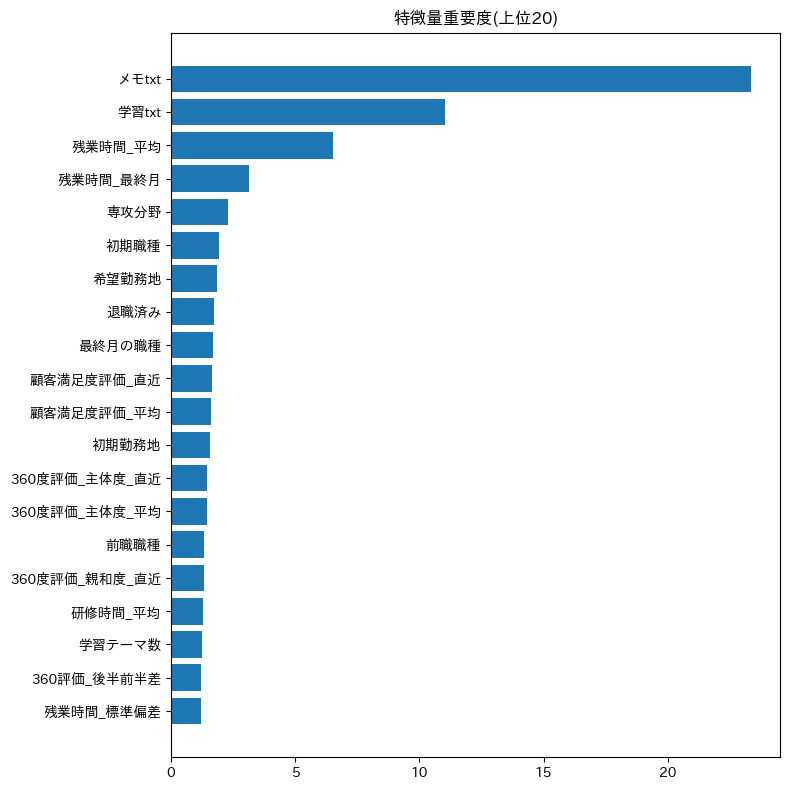

In [ ]:
# 特徴量重要度
重要度表 = pd.DataFrame({
    "列名": 特徴量.columns,
    "重要度": 分類器.get_feature_importance(),
}).sort_values("重要度", ascending=False)

plt.figure(figsize=(8, 8))
plt.barh(重要度表["列名"][:20][::-1], 重要度表["重要度"][:20][::-1])
plt.title("特徴量重要度(上位20)")
plt.tight_layout()
plt.show()

学習・メモ・残業が特徴量として大きくなっていることを確認。
最後に提出ファイルを作成する。ヘッダーなしで2列(社員ID、定着する確率)。

In [ ]:
# ヘッダー行がないためheader=None
提出見本 = pd.read_csv(f"{データ置き場}/sample_submission.csv", header=None)
提出見本.columns = ["社員ID", "見本値"]  # 見本値の列は使わない

# 見本のID順に自分の予測を並べ直す
提出データ = 提出見本[["社員ID"]].merge(
    pd.DataFrame({"社員ID": 予測データ["社員ID"], "定着確率": 最終予測}),
    on="社員ID", how="left")
assert 提出データ["定着確率"].notna().all(), "IDが不一致"

提出データ.to_csv("submission.csv", index=False, header=False)
print(提出データ.head())
print("行数:", len(提出データ))

      社員ID      定着確率
0  E000002  0.531806
1  E000003  0.444432
2  E000004  0.794118
3  E000006  0.433843
4  E000009  0.745825
行数: 2502
